# LDA 降维算法详解

## 什么是 LDA？

线性判别分析（`LDA`）是一种监督学习方法，常用于多类分类任务，兼具分类与降维功能。其核心思想是通过寻找特征的线性组合，将高维数据投影到低维空间（最大维度为类别数减一），以最大化类间差异、最小化类内差异，从而有效区分不同类别。

LDA 有时也被称为判别函数分析（`Discriminant Function Analysis`, DFA），属于生成式模型方法。它假设每个类别的数据满足高斯分布，且各类别共享相同的协方差矩阵。基于这些假设，`LDA` 通过贝叶斯定理计算新样本属于各类的后验概率，并选择概率最大的类别作为分类结果。

与逻辑回归不同，`LDA` 天然适用于多类分类任务，而逻辑回归则需通过扩展机制实现多类支持。`LDA` 既可以作为独立分类器使用，也常作为预处理步骤用于降维（例如先投影至低维空间，再结合支持向量机或决策树进行分类）。但需注意，`LDA` 的本质是分类模型，其降维功能服务于分类，而非专为“增强”其他模型而设计。

### 线性判别分析的起源

LDA 的起源可以追溯到 `1936` 年，由统计学家 `Ronald A. Fisher` 提出，他提出了著名的 **Fisher 线性判别法**（`Fisher's Linear Discriminant`）。`Fisher` 的方法最初用于二分类问题，其目标是在原始特征空间中寻找一个最佳的线性投影方向，使得投影后两类样本的均值间距最大，而类内方差最小，从而实现良好的类别区分。

后来，`C. R. Rao` 将这一方法推广为适用于多类分类的形式，并发展成为我们今天所说的线性判别分析。该方法本质上是一种同时实现分类与降维的统计技术，强调在保持类间分离度的同时降低数据的维度。

`Fisher `方法的**核心思想**是：将高维数据投影到一条或几条线性判别轴上，使得不同类别在该投影方向上的分布尽可能分离。这种“分离”通过最大化投影后各类别均值之间的距离（类间散度）与最小化类别内的方差（类内散度）共同实现。

### LDA 的实际应用

`LDA` 在线性分类问题中有广泛应用，下面以银行贷款审批为例说明其实际用途。

> 假设某家银行需要决定是否批准一位申请人的贷款申请。银行参考两个关键特征：申请人的信用评分和年收入。这两个特征可以表示在一个二维平面中，其中每个申请人对应一个点，标签为“批准”或“拒绝”。

如果仅根据某一个特征进行分类（如只看信用评分），可能存在类别重叠，难以准确划分。而 `LDA` 能够找到一个最佳的线性组合方向（即一个新轴），使得投影到该轴上的两个类别尽可能分离。

`LDA` 的做法是：

- 寻找一个线性投影方向，使得**不同类别的投影均值之间差异最大化**（类间散度最大）；
- 同时使得**每个类别内部的投影方差最小化**（类内散度最小）；

在图形上，这相当于在原始二维特征空间中绘制一条分隔线（或更一般地，一个投影轴），然后将所有数据点投影到这条线上。之后，可以在该一维空间中设置一个阈值来区分“批准”和“拒绝”的样本。

这种方法不仅提高了分类准确率，还能通过降维简化后续模型的复杂度。

### LDA 的属性和假设

`LDA` 的核心目标是在保留类别区分信息的前提下，将高维特征空间中的数据投影到一个更低维的线性子空间。对于一个具有 $n$ 个特征、$C$ 个类别的数据集，`LDA` 最多可将数据投影到 $k = C - 1$ 维的子空间中。

`LDA` 是一种典型的生成式模型，它假设每个类别的样本服从具有相同协方差矩阵的多元高斯分布。在建模过程中，`LDA` 需要对每个类别计算如下统计量：

- **类均值向量**（`Mean vector`）：反映该类样本在各个特征维度上的中心位置；
- **类内协方差矩阵**（`Covariance matrix`）：描述该类样本在特征空间中的分布形状和各特征之间的线性关系。

这些估计得到的参数用于构建判别函数，`LDA` 根据该函数对新样本进行分类预测。

`LDA` 的主要假设包括：

1. **每个类别的样本符合多元正态分布**（`Gaussian distribution`），即特征在每个类别内服从钟形分布；
2. **类别之间是线性可分的**，可以通过一个或多个线性判别边界进行区分；
3. **所有类别共享相同的协方差矩阵**，这意味着类别之间在分布形状上是一致的，仅均值位置不同。

需要注意的是，当这些假设不成立，尤其是在特征维度远大于样本数（即“高维小样本”）的情况下，`LDA` 的性能可能会显著下降。此时可能需要使用正则化 `LDA`、`QDA`（`Quadratic Discriminant Analysis`）或其他非线性方法作为替代。

## 特征向量和特征值的作用

在 `LDA` 的降维过程中，我们通过线性代数工具来寻找一个最优的投影方向，使得投影后的数据类别间尽可能分开。为此，`LDA` 借助 **特征值分解（或广义特征值问题）** 来确定最优的投影轴。

在数学上，`LDA` 构造了两个关键的散度矩阵：

- **类内散度矩阵（Within-class scatter matrix, $ S_W $）**：度量各个类别内部样本在特征空间中的离散程度。
- **类间散度矩阵（Between-class scatter matrix, $ S_B $）**：度量类别中心之间的离散程度，代表类别间的分离度。

`LDA` 的目标是找到一个投影矩阵 $ W $，使得下列比值最大化：

$$
J(W) = \frac{|W^T S_B W|}{|W^T S_W W|}
$$

这一优化问题的解可以通过解广义特征值问题得到：

$$
S_B \mathbf{v} = \lambda S_W \mathbf{v}
$$

其中：

- $ \mathbf{v} $ 是特征向量，代表投影方向；
- $ \lambda $ 是对应的特征值，表示该方向区分类别能力的强弱。

因此：

- **特征向量** 决定了新的投影轴（即降维后的方向）；
- **特征值** 表示每个投影方向上的判别能力，特征值越大，代表该方向对于类别区分越有效。

在降维时，我们通常选择前 $ k $ 个最大特征值对应的特征向量，构成降维矩阵 $ W_k $，并将原始数据投影到新的低维子空间中。

## 准备实施线性判别分析

要有效地使用 `LDA`，必须事先准备数据集。以下是实施 `LDA` 的步骤和最佳实践：

**1\. 对这些数据进行预处理，以确保其被规范化和中心化**

这一步是为了使各特征具有相同的尺度，避免在协方差计算中某些特征对结果产生不成比例的影响。标准化（如零均值单位方差）和中心化操作对于提升模型稳定性和效果非常重要。

**2\. 为低维空间选择一个适当的维数**

可通过传递 `LDA` 的 `n_components` 参数来实现，该参数用于标识要提取的线性判别向量（投影方向）的数量，最大值为类别数减一。选择合适的维度可以在保留判别信息的同时降低数据复杂度。

**3\. 对此模型进行正则化**

正则化旨在防止过拟合，即统计模型与训练数据拟合过度，从而降低在新数据上的预测准确度。可以使用带有 `shrinkage` 的 `LDA` 变体（如 `shrinkage='auto'`）在高维小样本的情况下提高模型稳定性。

**4\. 使用交叉验证来评估模型性能**

可以通过绘制混淆矩阵来评估如 `LDA` 等分类器的性能，将实际类值作为行，预测类值作为列。利用混淆矩阵，可以很容易地看出分类器是否混淆了两个类，即，将一个类错误地标记为另一个类。例如，有一个 `10 x 10` 混淆矩阵，预测从 `0` 到 `9` 的图像。在 `y` 轴上将实际值绘制为行，在 `x` 轴上将预测结果绘制为列。要查看分类器在 `10 x 10` 混淆矩阵示例中混淆 `4s` 和 `9s` 图像的次数，需要查看第 `4` 行和第 `9` 列。

![Confusion Matrix Example](https://www.ibm.com/content/dam/connectedassets-adobe-cms/worldwide-content/cdp/cf/ul/g/c0/c7/ConfusionMatrixExample.png)


## 线性判别函数的工作原理

线性判别函数可根据特征对数据点进行分离并将其归入不同的类或类别，从而帮助做出针对分类问题的决策。其计算流程可概括为以下几个关键步骤：

### 计算类间方差

类间方差是指不同类之间的可分离性，即类均值之间的距离。

### 计算类内方差

类内方差是类均值与样本之间的差别。

### 将数据投射到低维空间

这样可以实现类间方差最大，类内方差最小。我们可以用以下等式按照数学方法表示两个类的线性判别函数：

$$
\delta(x) = x \cdot \left( \sigma^2 (\mu_0 - \mu_1) - 2 \sigma^2 (\mu_0^2 - \mu_1^2) + \ln\left( \frac{P(\omega_0)}{P(\omega_1)} \right) \right)
$$

其中：

* $\delta(x)$ 表示线性判别函数；
* $x$ 表示输入数据点；
* $\mu_0$ 和 $\mu_1$ 是两个类的均值；
* $\sigma^2$ 是类内公共方差；
* $P(\omega_0)$ 和 $P(\omega_1)$ 为这两个类的先验概率。

### LDA 应用示例

我们使用此方程式来研究某一贷款审批示例。概括而言，银行正在决定是批准还是拒绝贷款申请。银行使用两个特征来做出此决策：申请人的信用评分 (x) 和年收入。银行已收集先前贷款申请人的历史数据，以及相关贷款是否已获得批准。

- **类 $\omega_0$** 表示“贷款被拒绝”  
- **类 $\omega_1$** 表示“贷款已批准”

利用线性判别函数，银行可以计算出每个贷款申请的分数 (**δ(x)**)。

线性判别函数的等式如下所示：

$$
\delta(x) = x \cdot \left( \sigma^2 (\mu_0 - \mu_1) - 2 \sigma^2 (\mu_0^2 - \mu_1^2) + \ln\left(\frac{P(\omega_0)}{P(\omega_1)}\right) \right)
$$

其中：

* $x$ 表示申请人的信用评分和年收入。
* $\mu_0$ 和 $\mu_1$ 是这两个类的相关特征的平均值：“贷款被拒绝”和“贷款已批准”。
* $\sigma^2$ 是类内公共方差。
* $P(\omega_0)$ 是“贷款被拒绝”的先验概率。
* $P(\omega_1)$ 是“贷款已批准”的先验概率。

银行计算每笔贷款申请的线性判别函数：

* 如果 $\delta(x) > 0$，则表明贷款申请更有可能获得批准。
* 如果 $\delta(x) < 0$，则表明贷款申请更有可能被拒绝。

于是，银行可自动运行其贷款审批流程，从而做出更快、更一致的决策，同时最大限度减少人为偏见。

### 线性判别分析的应用

这些是 `LDA` 可用于解决复杂问题，并帮助组织做出更好决策的典型场景。

* **金融领域**的信用风险评估为了降低风险，金融机构必须识别并最大限度地减少信用违约。`LDA` 可以通过筛选财务因素和行为数据，帮助从信誉良好的申请人中识别可能拖欠贷款的申请人。
* **医疗保健领域**的疾病诊断快速准确的疾病诊断对于实现有效的治疗至关重要。医院和医疗保健提供方必须解读大量医疗数据。`LDA` 可通过识别患者数据中的模式和关系来帮助简化复杂的数据集，同时提高诊断准确性。
* **电子商务领域**的客户细分为了有效营销，电子商务企业必须能够对不同的客户群进行分类。LDA 在细分客户方面发挥着关键作用，使电子商务公司能够针对不同的客户群体量身定制营销策略。其结果是带来更加个性化的购物体验，提高客户忠诚度和销售额。
* **制造领域**的质量控制在生产高质量产品的同时最大限度减少缺陷是一项基本挑战。来自机械的传感器数据可与 LDA 一起使用，从而识别与缺陷相关的模式。通过实时检测异常情况，制造商可立即采取纠正措施，从而提高产品质量并减少浪费。
* **营销领域**的营销活动优化您可通过使用个性化内容来定位对口的受众，从而最大化您的广告预算；然而，要确定相应的受众细分群体却可能十分困难。`LDA` 可通过对客户属性和行为进行分类来简化此流程，从而提升广告活动的定制化程度。此方法可带来更高的投资回报率 (`ROI`) 和更好的客户体验。

## 使用线性判别分析的优点和缺点

在将线性判别分析（`LDA`）应用于各种分类问题时，了解其优点和局限性至关重要。了解这些权衡有助于数据科学家和机器学习从业者判断其是否适用于特定任务。


###主要优势

- **计算简单高效：**  
  `LDA` 是一种简单而强大的算法。它易于理解和实现，因此对机器学习初学者非常友好。同时，它的计算效率高，能够快速输出结果。

- **适用于高维数据：**  
  当特征数量多于训练样本数量时，`LDA` 依然表现良好。因此，在如文本分析、图像识别、基因组学等高维数据领域中，`LDA` 特别有价值。

- **处理多重共线性：**  
  `LDA` 能够应对特征之间高度相关（共线性）的问题。通过将数据映射到低维空间，`LDA` 能保留尽可能多的判别信息。

### 主要缺点

- **类分布重叠时表现不佳：**  
  当不同类别的数据具有相似的均值或统计属性时，`LDA` 可能难以将其有效区分。例如，如果两种花的花瓣长度和宽度相似，`LDA` 就很难仅靠这两个特征准确分类。这种情况下，可能更适合使用如核方法等非线性技术。

- **不适用于无监督学习：**  
  作为监督学习方法，`LDA` 依赖于已有的标签数据来训练模型。相较之下，主成分分析（`PCA`）等无监督降维方法不依赖标签，更适合用于未标记数据。


准确率：0.98
混淆矩阵：
[[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]


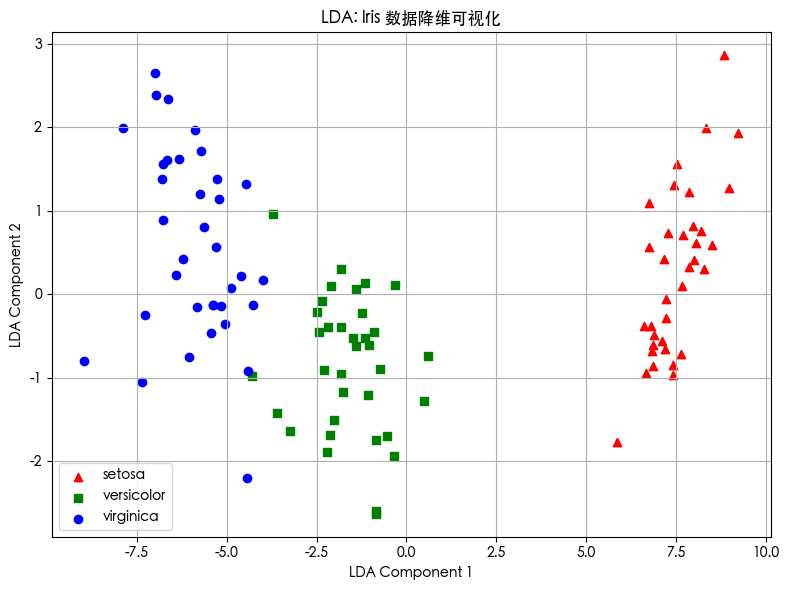

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import load_iris

from matplotlib import rcParams

# 配置 matplotlib 使用字体
rcParams['font.sans-serif'] = ['Heiti TC']
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 加载 Iris 数据集
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 拆分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# 创建 LDA 实例并拟合训练集
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

# 使用 Random Forest 进行分类
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_lda, y_train)

# 预测与评估
y_pred = clf.predict(X_test_lda)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"准确率：{acc:.2f}")
print("混淆矩阵：")
print(cm)

# 可视化 LDA 转换结果
plt.figure(figsize=(8, 6))
for label, marker, color in zip(range(3), ('^', 's', 'o'), ('red', 'green', 'blue')):
    plt.scatter(X_train_lda[y_train == label, 0],
                X_train_lda[y_train == label, 1],
                label=target_names[label],
                marker=marker,
                color=color)
plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.title("LDA: Iris 数据降维可视化")
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()